# Chapter 2: Modelling

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from feature_engine.encoding import WoEEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score
from netcal.metrics import ECE


df = pd.read_csv('data/processed/pd_dataset.csv')

df.head()

,id,application_type,loan_amnt,term,purpose,int_rate,grade,emp_length,home_ownership,issue_d,...,open_acc,revol_util,revol_bal,pub_rec_bankruptcies,loan_status,application_income,application_dti,application_verification,application_fico,credit_history_months
0,68407277,Individual,3600.0,36 months,debt_consolidation,13.99,C,10+ years,MORTGAGE,2015,...,7.0,29.7,2765.0,0.0,Fully Paid,55000.0,5.91,Not Verified,677.0,150
1,68355089,Individual,24700.0,36 months,small_business,11.99,C,10+ years,MORTGAGE,2015,...,22.0,19.2,21470.0,0.0,Fully Paid,65000.0,16.06,Not Verified,717.0,194
2,68341763,Joint App,20000.0,60 months,home_improvement,10.78,B,10+ years,MORTGAGE,2015,...,6.0,56.2,7869.0,0.0,Fully Paid,71000.0,13.85,Not Verified,697.0,186
3,68476807,Individual,10400.0,60 months,major_purchase,22.45,F,3 years,MORTGAGE,2015,...,12.0,64.5,21929.0,0.0,Fully Paid,104433.0,25.37,Source Verified,697.0,213
4,68426831,Individual,11950.0,36 months,debt_consolidation,13.44,C,4 years,RENT,2015,...,5.0,68.4,8822.0,0.0,Fully Paid,34000.0,10.20,Source Verified,692.0,342


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1343422 entries, 0 to 1343421
Data columns (total 22 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   id                        1343422 non-null  int64  
 1   application_type          1343422 non-null  object 
 2   loan_amnt                 1343422 non-null  float64
 3   term                      1343422 non-null  object 
 4   purpose                   1343422 non-null  object 
 5   int_rate                  1343422 non-null  float64
 6   grade                     1343422 non-null  object 
 7   emp_length                1343422 non-null  object 
 8   home_ownership            1343422 non-null  object 
 9   issue_d                   1343422 non-null  int64  
 10  inq_last_6mths            1343422 non-null  float64
 11  delinq_2yrs               1343422 non-null  float64
 12  open_acc                  1343422 non-null  float64
 13  revol_util                1

## Preprocessing

In [3]:
# biary format target
df['loan_status'] = (df['loan_status'] == 'Default').astype(int)

df['loan_status']

0          0
1          0
2          0
3          0
4          0
          ..
1343417    0
1343418    0
1343419    1
1343420    0
1343421    1
Name: loan_status, Length: 1343422, dtype: int64

### Categoric Features

In [4]:
cat_cols = df.select_dtypes(include=['object', 'category'])

cat_cols.columns.tolist()

['application_type',
 'term',
 'purpose',
 'grade',
 'emp_length',
 'home_ownership',
 'application_verification']

In [5]:
cat_cols.head()

,application_type,term,purpose,grade,emp_length,home_ownership,application_verification
0,Individual,36 months,debt_consolidation,C,10+ years,MORTGAGE,Not Verified
1,Individual,36 months,small_business,C,10+ years,MORTGAGE,Not Verified
2,Joint App,60 months,home_improvement,B,10+ years,MORTGAGE,Not Verified
3,Individual,60 months,major_purchase,F,3 years,MORTGAGE,Source Verified
4,Individual,36 months,debt_consolidation,C,4 years,RENT,Source Verified


In [6]:
# joint application type flagger
df['application_type'] = (df['application_type'] == 'Joint App').astype(int)

# convert term strings into int-types
df['term'] = df['term'].str.strip(' months').astype(int)

# application verified flagger
df['application_verification'] = (df['application_verification'].isin(['Source Verified', 'Verified'])).astype(int)

df[['application_type', 'term', 'application_verification']].head()

,application_type,term,application_verification
0,0,36,0
1,0,36,0
2,1,60,0
3,0,60,1
4,0,36,1


In [7]:
# missing employment flag
df['is_emp_missing'] = (df['emp_length'] == 'Unknown').astype(int)

emp_length_map = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10,
    'Unknown': np.nan
}
df['emp_length'] = df['emp_length'].map(emp_length_map)

# impute 'unknown'/ missing employment data with median
median_emp = df['emp_length'].median()
df['emp_length'] = df['emp_length'].fillna(median_emp)

df[df['is_emp_missing'] > 0][['emp_length', 'is_emp_missing']].head()

,emp_length,is_emp_missing
60,6.0,1
77,6.0,1
117,6.0,1
119,6.0,1
123,6.0,1


### Skew-Handling: Log Transformations

In [8]:
numeric_cols = df.select_dtypes(exclude=['object', 'category'])
numeric_cols_list = numeric_cols.columns.to_list()

# features with a skew level higher than 0.5 - consider log-tranforming 
skewed_features = []
for feature in numeric_cols_list:
    skew_value = df[feature].skew()
    if abs(skew_value) > 1:
        skewed_features.append((feature, skew_value.round(2)))

skewed_df = pd.DataFrame(skewed_features, columns=['feature', 'skew'])
skewed_df.sort_values('skew', ascending=False, ignore_index=True)

,feature,skew
0,application_income,45.61
1,revol_bal,13.76
2,application_type,7.07
3,delinq_2yrs,5.61
4,is_emp_missing,3.78
5,pub_rec_bankruptcies,3.44
6,inq_last_6mths,1.70
7,loan_status,1.50
8,open_acc,1.30
9,application_fico,1.27


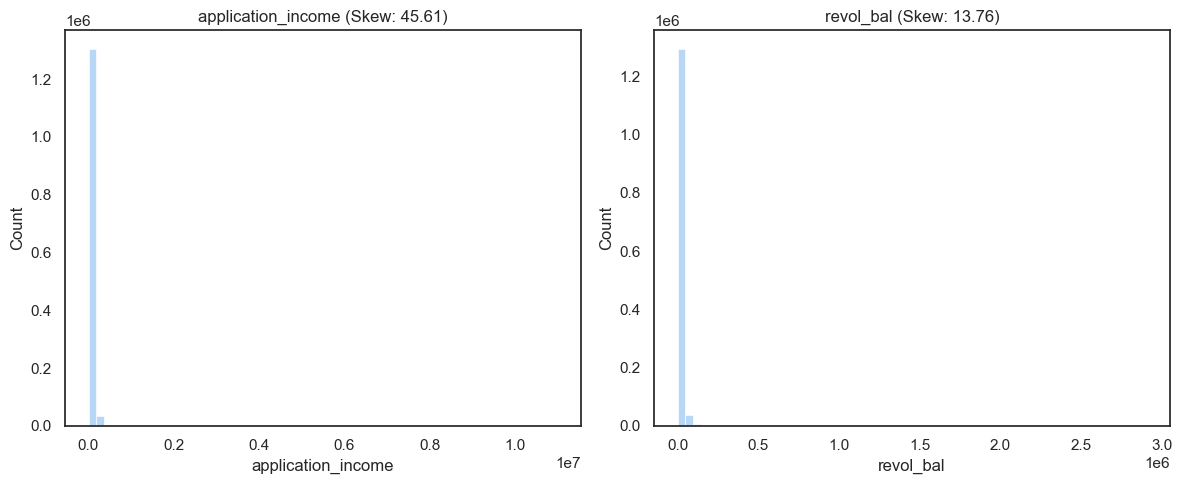

In [9]:
sns.set_theme(style='white', palette='pastel')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='application_income', bins=60)
plt.title(f'application_income (Skew: {df['application_income'].skew().round(2)})')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='revol_bal', bins=60)
plt.title(f'revol_bal (Skew: {df['revol_bal'].skew().round(2)})')

plt.tight_layout()
plt.show()

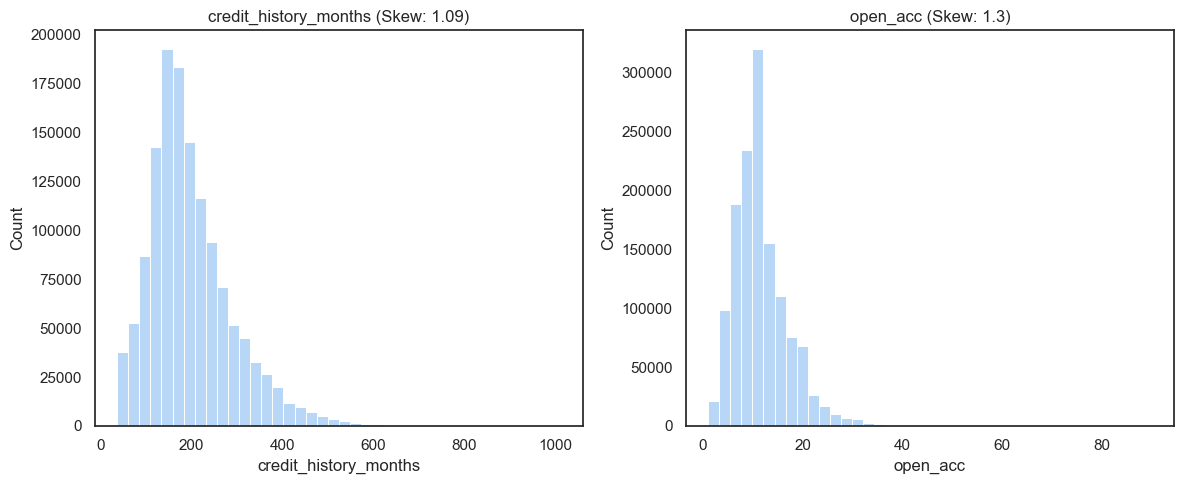

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='credit_history_months', bins=40)
plt.title(f'credit_history_months (Skew: {df['credit_history_months'].skew().round(2)})')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='open_acc', bins=40)
plt.title(f'open_acc (Skew: {df['open_acc'].skew().round(2)})')

plt.tight_layout()
plt.show()

## Train-Validate-Test Split

In [11]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# train & testset split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [12]:
# raw portfolio df - derived from testset
portfolio_df = X_test.copy()
portfolio_df['loan_status'] = y_test

# drop id column
X_test = X_test.drop(columns=['id'])
X_train = X_train.drop(columns=['id'])

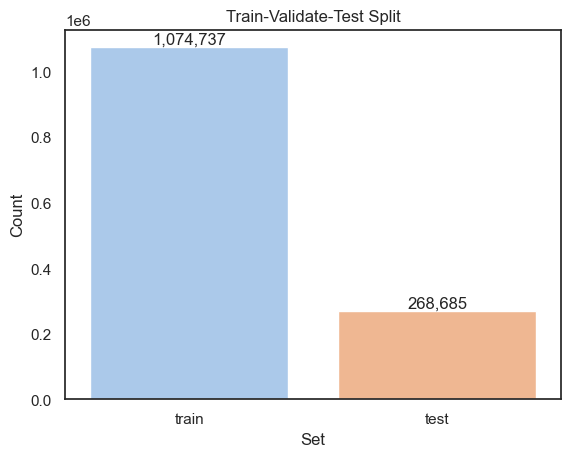

In [13]:
split_df = pd.DataFrame({
    'set': ['train', 'test'],
    'count': [len(X_train), len(X_test)]
})

split_ax = sns.barplot(data=split_df, x='set', y='count', hue='set')
for container in split_ax.containers:
    split_ax.bar_label(container, fmt='{:,.0f}')
plt.title('Train-Validate-Test Split')
plt.xlabel('Set')
plt.ylabel('Count')
plt.show()

## Preprocessing Pipelines

In [14]:
df['grade'].unique()

array(['C', 'B', 'F', 'A', 'E', 'D', 'G'], dtype=object)

In [15]:
# WoE grade enconding (logisitc & neural net)
woe = WoEEncoder(variables=['grade'])
X_train_woe = woe.fit_transform(X_train, y_train)
X_test_woe = woe.transform(X_test)

# ordinal encoding (tree-based models)
ordinal = OrdinalEncoder(categories=[['A', 'B', 'C', 'D', 'E', 'F', 'G']])

X_train_ord = X_train.copy()
X_test_ord = X_test.copy()

X_train_ord['grade'] = ordinal.fit_transform(X_train[['grade']])
X_test_ord['grade'] = ordinal.transform(X_test[['grade']])

In [16]:
X_test.columns.to_list()

['application_type',
 'loan_amnt',
 'term',
 'purpose',
 'int_rate',
 'grade',
 'emp_length',
 'home_ownership',
 'issue_d',
 'inq_last_6mths',
 'delinq_2yrs',
 'open_acc',
 'revol_util',
 'revol_bal',
 'pub_rec_bankruptcies',
 'application_income',
 'application_dti',
 'application_verification',
 'application_fico',
 'credit_history_months',
 'is_emp_missing']

In [17]:
# feature groups
log_transform_cols = ['application_income', 'revol_bal']

categoric_cols = ['purpose', 'home_ownership']

numeric_cols = [
    'loan_amnt', 'emp_length', 'int_rate',
    'inq_last_6mths', 'delinq_2yrs', 'open_acc',
    'revol_util', 'pub_rec_bankruptcies','application_dti', 
    'application_fico', 'credit_history_months'
]

In [18]:
# linear & neural net preporcessor
log_transformer = Pipeline(steps=[
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

num_tranformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

lr_cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first', 
                              handle_unknown='infrequent_if_exist', 
                              sparse_output=False,
                              min_frequency=10000))
])

lr_preprocessor = ColumnTransformer(transformers=[
    ('log', log_transformer, log_transform_cols),
    ('num', num_tranformer, numeric_cols),
    ('cat', lr_cat_transformer, categoric_cols)
], remainder='passthrough')

In [19]:
# tree-based preprocessor
cat_transformer_tree = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='infrequent_if_exist', 
                              sparse_output=False,
                              min_frequency=10000))
])

tree_preprocessor = ColumnTransformer(transformers=[
    ('cat', cat_transformer_tree, categoric_cols)
], remainder='passthrough')

## Modeling

### Logistic Regression

In [20]:
logreg_pipeline = Pipeline([
    ('preprocessor', lr_preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# train
logreg_pipeline.fit(X_train_woe, y_train)

# predict
lr_prob = logreg_pipeline.predict_proba(X_test_woe)[:, 1]

c:\Users\touns\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
# validation
ece_metric = ECE()

lr_roc = roc_auc_score(y_test, lr_prob)
lr_brier = brier_score_loss(y_test, lr_prob)
lr_ece = ece_metric.measure(lr_prob, y_test.to_numpy())

print('Logistic Regression:')
print(f'AUC-ROC Score: {lr_roc:.3f}')
print(f'Brier Score: {lr_brier:.3f}')
print(f'ECE Score: {lr_ece:.3f}')

Logistic Regression:
AUC-ROC Score: 0.713
Brier Score: 0.145
ECE Score: 0.003


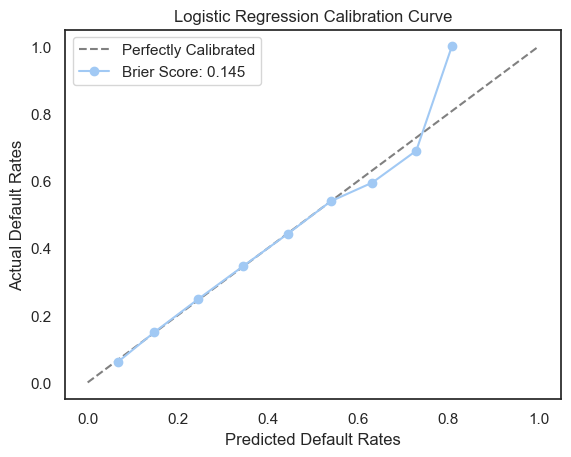

In [22]:
# calibration curve
lr_prob_true, lr_prob_pred = calibration_curve(y_test, lr_prob, n_bins=10)

plt.plot([0, 1], [0, 1], linestyle='--', c='grey', label='Perfectly Calibrated')
plt.plot(lr_prob_pred, lr_prob_true, marker='o', label=f'Brier Score: {lr_brier:.3f}')
plt.title('Logistic Regression Calibration Curve')
plt.xlabel('Predicted Default Rates')
plt.ylabel('Actual Default Rates')
plt.legend(loc='best')
plt.show()

In [23]:
logreg_model = logreg_pipeline.named_steps['model']
logreg_coef = logreg_model.coef_.ravel()
logreg_features = logreg_pipeline[:-1].get_feature_names_out()

logreg_coef_df = pd.DataFrame({
    'feature': logreg_features,
    'coef': logreg_coef,
    'abs_coef': abs(logreg_coef)
}).sort_values(by='abs_coef', ascending=False, ignore_index=True)

logreg_10 = logreg_coef_df.head(10).copy()
logreg_10['feature'] = logreg_10['feature'].str.split('__', n=1).str[-1]

logreg_10

,feature,coef,abs_coef
0,grade,0.490261,0.490261
1,is_emp_missing,0.438665,0.438665
2,home_ownership_RENT,0.341501,0.341501
3,purpose_small_business,0.329147,0.329147
4,application_fico,-0.203418,0.203418
5,application_type,0.186873,0.186873
6,home_ownership_OWN,0.168584,0.168584
7,application_dti,0.157308,0.157308
8,loan_amnt,0.148293,0.148293
9,application_income,-0.129581,0.129581


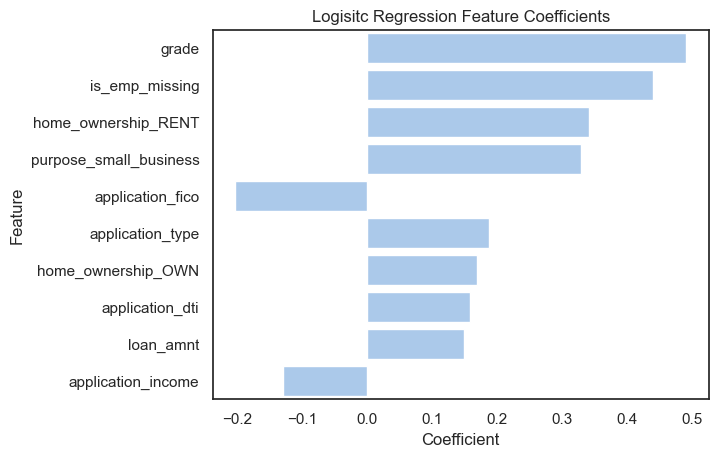

In [24]:
sns.barplot(data=logreg_10, x='coef', y='feature')
plt.title('Logisitc Regression Feature Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.xticks()
plt.show()

### XGBoost

In [25]:
xgb_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', XGBClassifier(random_state=42))
])

# train
xgb_pipeline.fit(X_train_ord, y_train)

# predict
xgb_prob = xgb_pipeline.predict_proba(X_test_ord)[:, 1]

In [26]:
# validation
xgb_roc = roc_auc_score(y_test, xgb_prob)
xgb_brier = brier_score_loss(y_test, xgb_prob)
xgb_ece = ece_metric.measure(xgb_prob, y_test.to_numpy())

print('XGBoost:')
print(f'AUC-ROC Score: {xgb_roc:.3f}')
print(f'Brier Score: {xgb_brier:.3f}')
print(f'ECE Score: {xgb_ece:.3f}')

XGBoost:
AUC-ROC Score: 0.729
Brier Score: 0.142
ECE Score: 0.002


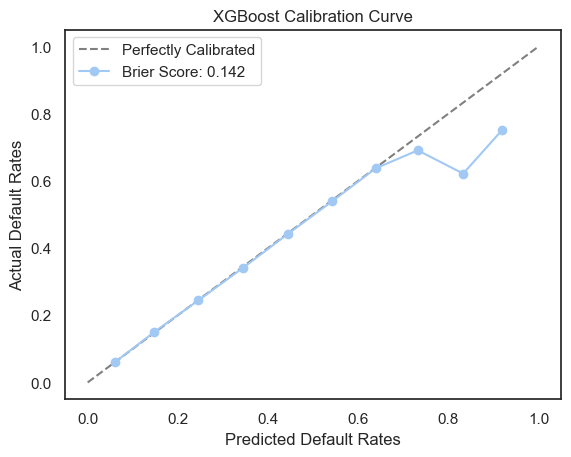

In [27]:
# calibration curve
xgb_prob_true, xgb_prob_pred = calibration_curve(y_test, xgb_prob, n_bins=10)

plt.plot([0, 1], [0, 1], linestyle='--', c='grey', label='Perfectly Calibrated')
plt.plot(xgb_prob_pred, xgb_prob_true, marker='o', label=f'Brier Score: {xgb_brier:.3f}')
plt.title('XGBoost Calibration Curve')
plt.xlabel('Predicted Default Rates')
plt.ylabel('Actual Default Rates')
plt.legend(loc='best')
plt.show()

In [28]:
xgb_model = xgb_pipeline.named_steps["model"]
xgb_importances = xgb_model.feature_importances_
xgb_features = xgb_pipeline[:-1].get_feature_names_out()

xgb_importance_df = pd.DataFrame(
    {"feature": xgb_features, 
     "importance": xgb_importances}
).sort_values(by="importance", ascending=False, ignore_index=True)

xgb_10 = xgb_importance_df.head(10).copy()
xgb_10["feature"] = xgb_10["feature"].str.split("__", n=1).str[-1]

xgb_10

,feature,importance
0,grade,0.581596
1,term,0.065672
2,home_ownership_RENT,0.060084
3,int_rate,0.042396
4,home_ownership_MORTGAGE,0.032752
5,is_emp_missing,0.029858
6,issue_d,0.024913
7,application_verification,0.014562
8,purpose_small_business,0.012255
9,application_fico,0.010882


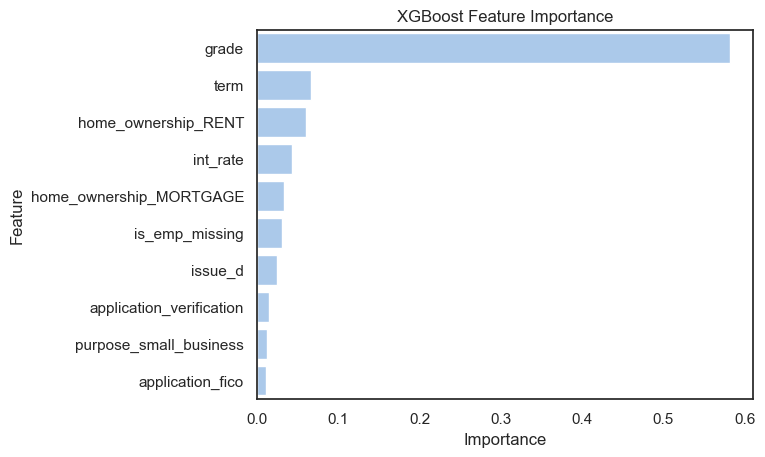

In [29]:
sns.barplot(data=xgb_10, x='importance', y='feature')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.xticks()
plt.show()

### Random Forest

In [30]:
rf_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# train
rf_pipeline.fit(X_train_ord, y_train)

# predict
rf_prob = rf_pipeline.predict_proba(X_test_ord)[:, 1]

In [31]:
# validation
rf_roc = roc_auc_score(y_test, rf_prob)
rf_brier = brier_score_loss(y_test, rf_prob)
rf_ece = ece_metric.measure(rf_prob, y_test.to_numpy())


print('Random Forest:')
print(f'AUC-ROC Score: {rf_roc:.3f}')
print(f'Brier Score: {rf_brier:.3f}')
print(f'ECE Score: {rf_ece:.3f}')

Random Forest:
AUC-ROC Score: 0.713
Brier Score: 0.144
ECE Score: 0.014


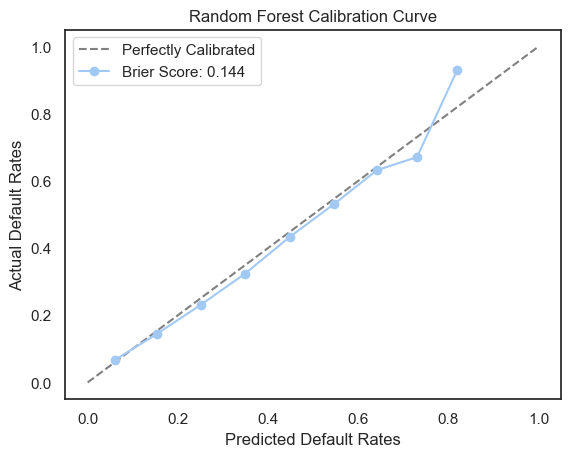

In [32]:
# calibration curve
rf_prob_true, rf_prob_pred = calibration_curve(y_test, rf_prob, n_bins=10)

plt.plot([0, 1], [0, 1], linestyle='--', c='grey', label='Perfectly Calibrated')
plt.plot(rf_prob_pred, rf_prob_true, marker='o', label=f'Brier Score: {rf_brier:.3f}')
plt.title('Random Forest Calibration Curve')
plt.xlabel('Predicted Default Rates')
plt.ylabel('Actual Default Rates')
plt.legend(loc='best')
plt.show()

In [33]:
rf_model = rf_pipeline.named_steps["model"]
rf_importances = rf_model.feature_importances_
rf_features = rf_pipeline[:-1].get_feature_names_out()

rf_importance_df = pd.DataFrame(
    {"feature": rf_features, 
     "importance": rf_importances}
).sort_values(by="importance", ascending=False, ignore_index=True)

rf_10 = rf_importance_df.head(10).copy()
rf_10["feature"] = rf_10["feature"].str.split("__", n=1).str[-1]

rf_10

,feature,importance
0,application_dti,0.097895
1,revol_bal,0.093598
2,revol_util,0.091524
3,credit_history_months,0.090753
4,int_rate,0.087668
5,application_income,0.084593
6,loan_amnt,0.077541
7,open_acc,0.063798
8,application_fico,0.058673
9,emp_length,0.042986


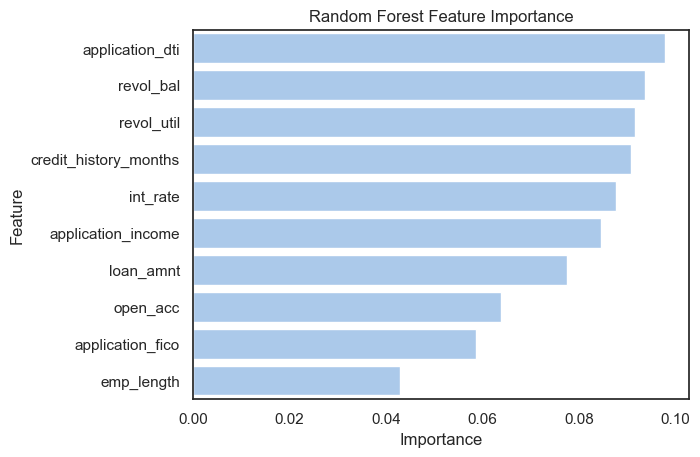

In [34]:
sns.barplot(data=rf_10, x='importance', y='feature')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.xticks()
plt.show()

### MLP Neural Network

In [35]:
mlp_pipeline = Pipeline([
    ('preprocessor', lr_preprocessor),
    ('model', MLPClassifier(random_state=42, early_stopping=True))
])

# train
mlp_pipeline.fit(X_train_woe, y_train)

# predict
mlp_prob = mlp_pipeline.predict_proba(X_test_woe)[:, 1]

In [36]:
# validation
mlp_roc = roc_auc_score(y_test, mlp_prob)
mlp_brier = brier_score_loss(y_test, mlp_prob)
mlp_ece = ece_metric.measure(mlp_prob, y_test.to_numpy())


print('MLP Neural Network:')
print(f'AUC-ROC Score: {mlp_roc:.3f}')
print(f'Brier Score: {mlp_brier:.3f}')
print(f'ECE Score: {mlp_ece:.3f}')

MLP Neural Network:
AUC-ROC Score: 0.713
Brier Score: 0.146
ECE Score: 0.028


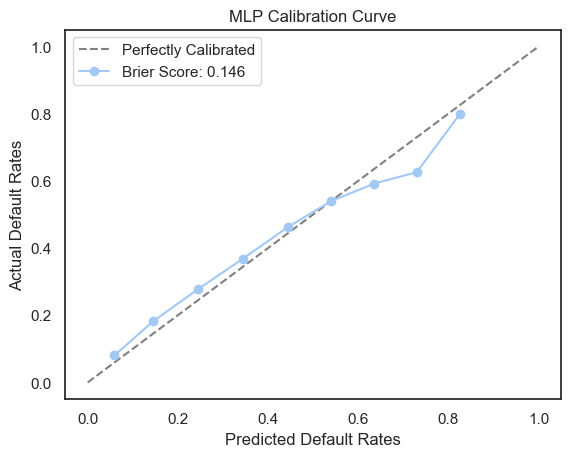

In [37]:
# calibration curve
mlp_prob_true, mlp_prob_pred = calibration_curve(y_test, mlp_prob, n_bins=10)

plt.plot([0, 1], [0, 1], linestyle='--', c='grey', label='Perfectly Calibrated')
plt.plot(mlp_prob_pred, mlp_prob_true, marker='o', label=f'Brier Score: {mlp_brier:.3f}')
plt.title('MLP Calibration Curve')
plt.xlabel('Predicted Default Rates')
plt.ylabel('Actual Default Rates')
plt.legend(loc='best')
plt.show()

In [38]:
# extract the fitted MLP model
mlp_model = mlp_pipeline.named_steps["model"]
mlp_importances = np.mean(np.abs(mlp_model.coefs_[0]), axis=1)
mlp_features = mlp_pipeline[:-1].get_feature_names_out()

mlp_importance_df = pd.DataFrame(
    {"feature": mlp_features, 
     "importance": mlp_importances}
).sort_values(by="importance", ascending=False, ignore_index=True)

mlp_10 = mlp_importance_df.head(10).copy()
mlp_10["feature"] = mlp_10["feature"].str.split("__", n=1).str[-1]

mlp_10

,feature,importance
0,grade,0.064689
1,is_emp_missing,0.063700
2,application_fico,0.063369
3,purpose_small_business,0.062522
4,term,0.060933
5,int_rate,0.058451
6,issue_d,0.057500
7,pub_rec_bankruptcies,0.057017
8,home_ownership_RENT,0.057003
9,purpose_credit_card,0.056865


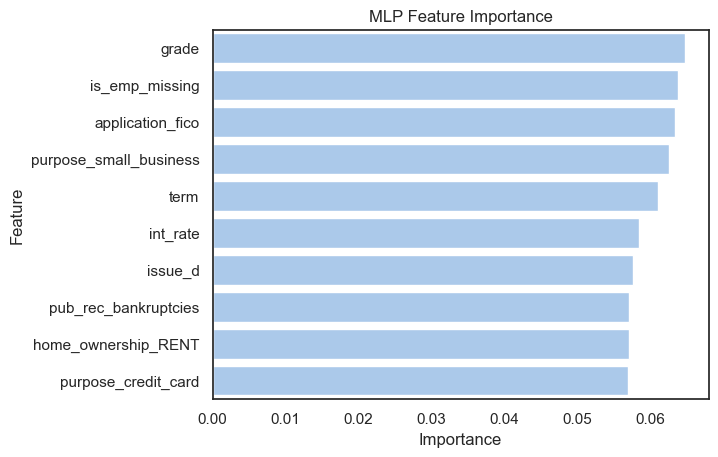

In [39]:
sns.barplot(data=mlp_10, x='importance', y='feature')
plt.title('MLP Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.xticks()
plt.show()

### LightGBM

In [40]:
lgbm_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', LGBMClassifier(
        force_row_wise=True,
        learning_rate=0.05,
        random_state=42
    ))
])

# train
lgbm_pipeline.fit(X_train_ord, y_train)

# predict
lgbm_prob = lgbm_pipeline.predict_proba(X_test_ord)[:, 1]

[LightGBM] [Info] Number of positive: 214584, number of negative: 860153
[LightGBM] [Info] Total Bins 2025
[LightGBM] [Info] Number of data points in the train set: 1074737, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199662 -> initscore=-1.388409
[LightGBM] [Info] Start training from score -1.388409


In [41]:
# validation
lgbm_roc = roc_auc_score(y_test, lgbm_prob)
lgbm_brier = brier_score_loss(y_test, lgbm_prob)
lgbm_ece = ece_metric.measure(lgbm_prob, y_test.to_numpy())


print('LightGBM')
print(f'AUC-ROC Score: {lgbm_roc:.3f}')
print(f'Brier Score: {lgbm_brier:.3f}')
print(f'ECE Score: {lgbm_ece:.3f}')

LightGBM
AUC-ROC Score: 0.725
Brier Score: 0.142
ECE Score: 0.006


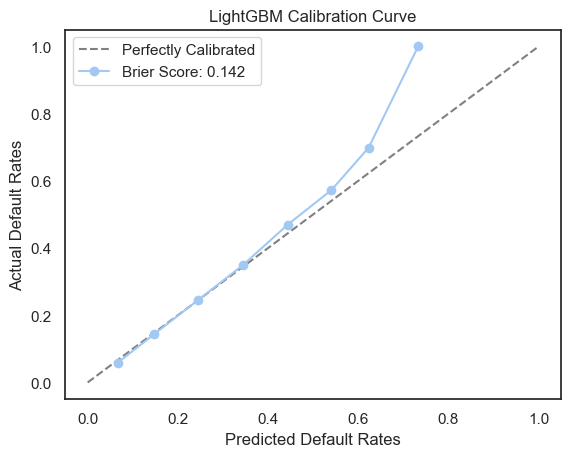

In [42]:
# calibration curve
lgbm_prob_true, lgbm_prob_pred = calibration_curve(y_test, lgbm_prob, n_bins=10)

plt.plot([0, 1], [0, 1], linestyle='--', c='grey', label='Perfectly Calibrated')
plt.plot(lgbm_prob_pred, lgbm_prob_true, marker='o', label=f'Brier Score: {lgbm_brier:.3f}')
plt.title('LightGBM Calibration Curve')
plt.xlabel('Predicted Default Rates')
plt.ylabel('Actual Default Rates')
plt.legend(loc='best')
plt.show()

In [43]:
lgbm_model = lgbm_pipeline.named_steps["model"]
lgbm_importances = lgbm_model.feature_importances_
lgbm_features = lgbm_pipeline[:-1].get_feature_names_out()

lgbm_importance_df = pd.DataFrame(
    {"feature": lgbm_features, 
     "importance": lgbm_importances}
).sort_values(by="importance", ascending=False, ignore_index=True)

lgbm_10 = lgbm_importance_df.head(10).copy()
lgbm_10["feature"] = lgbm_10["feature"].str.split("__", n=1).str[-1]

lgbm_10

,feature,importance
0,issue_d,389
1,loan_amnt,315
2,application_fico,278
3,application_income,269
4,application_dti,230
5,term,191
6,revol_bal,182
7,int_rate,179
8,is_emp_missing,154
9,credit_history_months,120


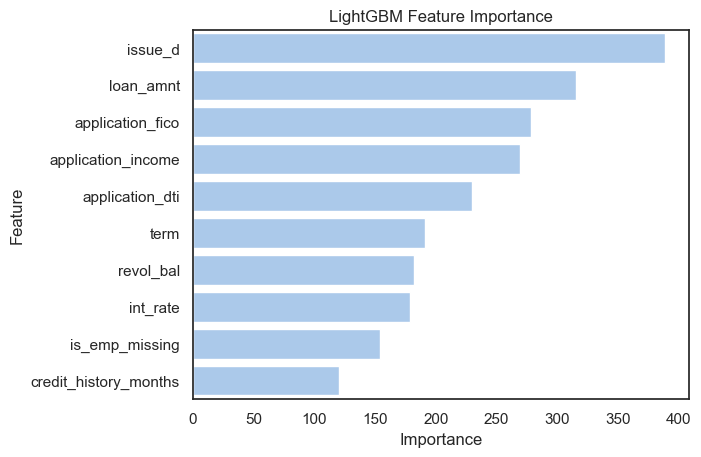

In [44]:
sns.barplot(data=lgbm_10, x='importance', y='feature')
plt.title('LightGBM Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.xticks()
plt.show()

## Analysis

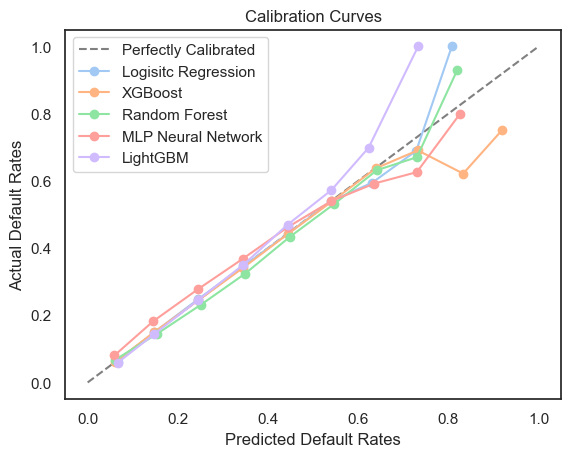

In [45]:
plt.plot([0, 1], [0, 1], linestyle='--', c='grey', label='Perfectly Calibrated')

plt.plot(lr_prob_pred, lr_prob_true, marker='o', label=f'Logisitc Regression')
plt.plot(xgb_prob_pred, xgb_prob_true, marker='o', label=f'XGBoost')
plt.plot(rf_prob_pred, rf_prob_true, marker='o', label=f'Random Forest')
plt.plot(mlp_prob_pred, mlp_prob_true, marker='o', label=f'MLP Neural Network')
plt.plot(lgbm_prob_pred, lgbm_prob_true, marker='o', label=f'LightGBM')

plt.title('Calibration Curves')
plt.xlabel('Predicted Default Rates')
plt.ylabel('Actual Default Rates')
plt.legend(loc='best')
plt.show()

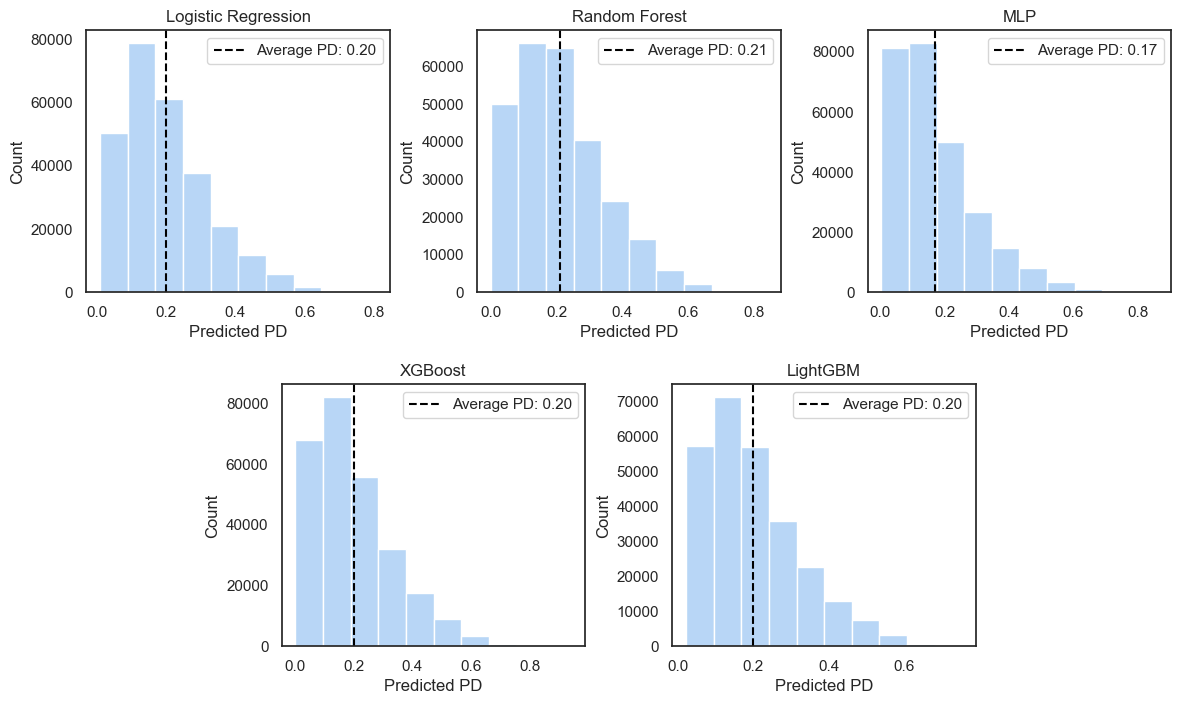

In [46]:
plots_data = [
    ('Logistic Regression', lr_prob, (0, slice(0, 2))), 
    ('Random Forest', rf_prob, (0, slice(2, 4))), 
    ('MLP', mlp_prob, (0, slice(4, 6))),
    ('XGBoost', xgb_prob, (1, slice(1, 3))), 
    ('LightGBM', lgbm_prob, (1, slice(3, 5))),
]

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.35, wspace=0.80)

for title, prob_data, (row, col) in plots_data:
    ax = fig.add_subplot(gs[row, col])

    sns.histplot(prob_data, bins=10, ax=ax)

    mean_val = prob_data.mean()
    ax.axvline(mean_val, c='black', ls='--', label=f'Average PD: {mean_val:,.2f}')

    ax.set_title(title)
    ax.set_xlabel('Predicted PD')
    ax.set_ylabel('Count')
    ax.legend()


plt.show()

## Portfolio Construction

In [47]:
portfolio_df.columns.to_list()

['id',
 'application_type',
 'loan_amnt',
 'term',
 'purpose',
 'int_rate',
 'grade',
 'emp_length',
 'home_ownership',
 'issue_d',
 'inq_last_6mths',
 'delinq_2yrs',
 'open_acc',
 'revol_util',
 'revol_bal',
 'pub_rec_bankruptcies',
 'application_income',
 'application_dti',
 'application_verification',
 'application_fico',
 'credit_history_months',
 'is_emp_missing',
 'loan_status']

In [48]:
portfolio_cols = [
    'id',
    'loan_amnt',
    'int_rate',
    'term',
    'grade',
    'purpose',
    'home_ownership',
    'application_income',
    'loan_status'
]

# logisitc regression portfolio
lr_portfolio = portfolio_df[portfolio_cols].copy()
lr_portfolio['pd'] = lr_prob

# random forest portfolio
rf_portfolio = portfolio_df[portfolio_cols].copy()
rf_portfolio['pd'] = rf_prob 

# xgboost portfolio
xgb_portfolio = portfolio_df[portfolio_cols].copy()
xgb_portfolio['pd'] = xgb_prob

# mlp portfolio
mlp_portfolio = portfolio_df[portfolio_cols].copy()
mlp_portfolio['pd'] = mlp_prob

# lightgbm portfolio
lgbm_portfolio = portfolio_df[portfolio_cols].copy()
lgbm_portfolio['pd'] = lgbm_prob

lr_portfolio.head()

,id,loan_amnt,int_rate,term,grade,purpose,home_ownership,application_income,loan_status,pd
1173827,1349345,10000.0,14.65,36,C,credit_card,RENT,50000.0,1,0.254486
1292586,95046538,7500.0,10.49,36,B,debt_consolidation,MORTGAGE,80000.0,0,0.105658
458058,81405218,8400.0,25.44,36,F,debt_consolidation,RENT,28000.0,0,0.471985
813553,17222736,28000.0,14.49,60,C,credit_card,RENT,150000.0,0,0.313372
653326,69442857,12000.0,6.49,36,A,debt_consolidation,MORTGAGE,45000.0,0,0.051545


In [50]:
os.makedirs('data/predictions', exist_ok=True)

portfolios = {
    'lr': lr_portfolio,
    'mlp': mlp_portfolio,
    'rf': rf_portfolio,
    'xgb': xgb_portfolio,
    'lgbm': lgbm_portfolio
}

for name, df in portfolios.items():
    file_path = f'data/predictions/{name}_portfolio.csv'
    df.to_csv(file_path, index=False)